# Loading The Dox
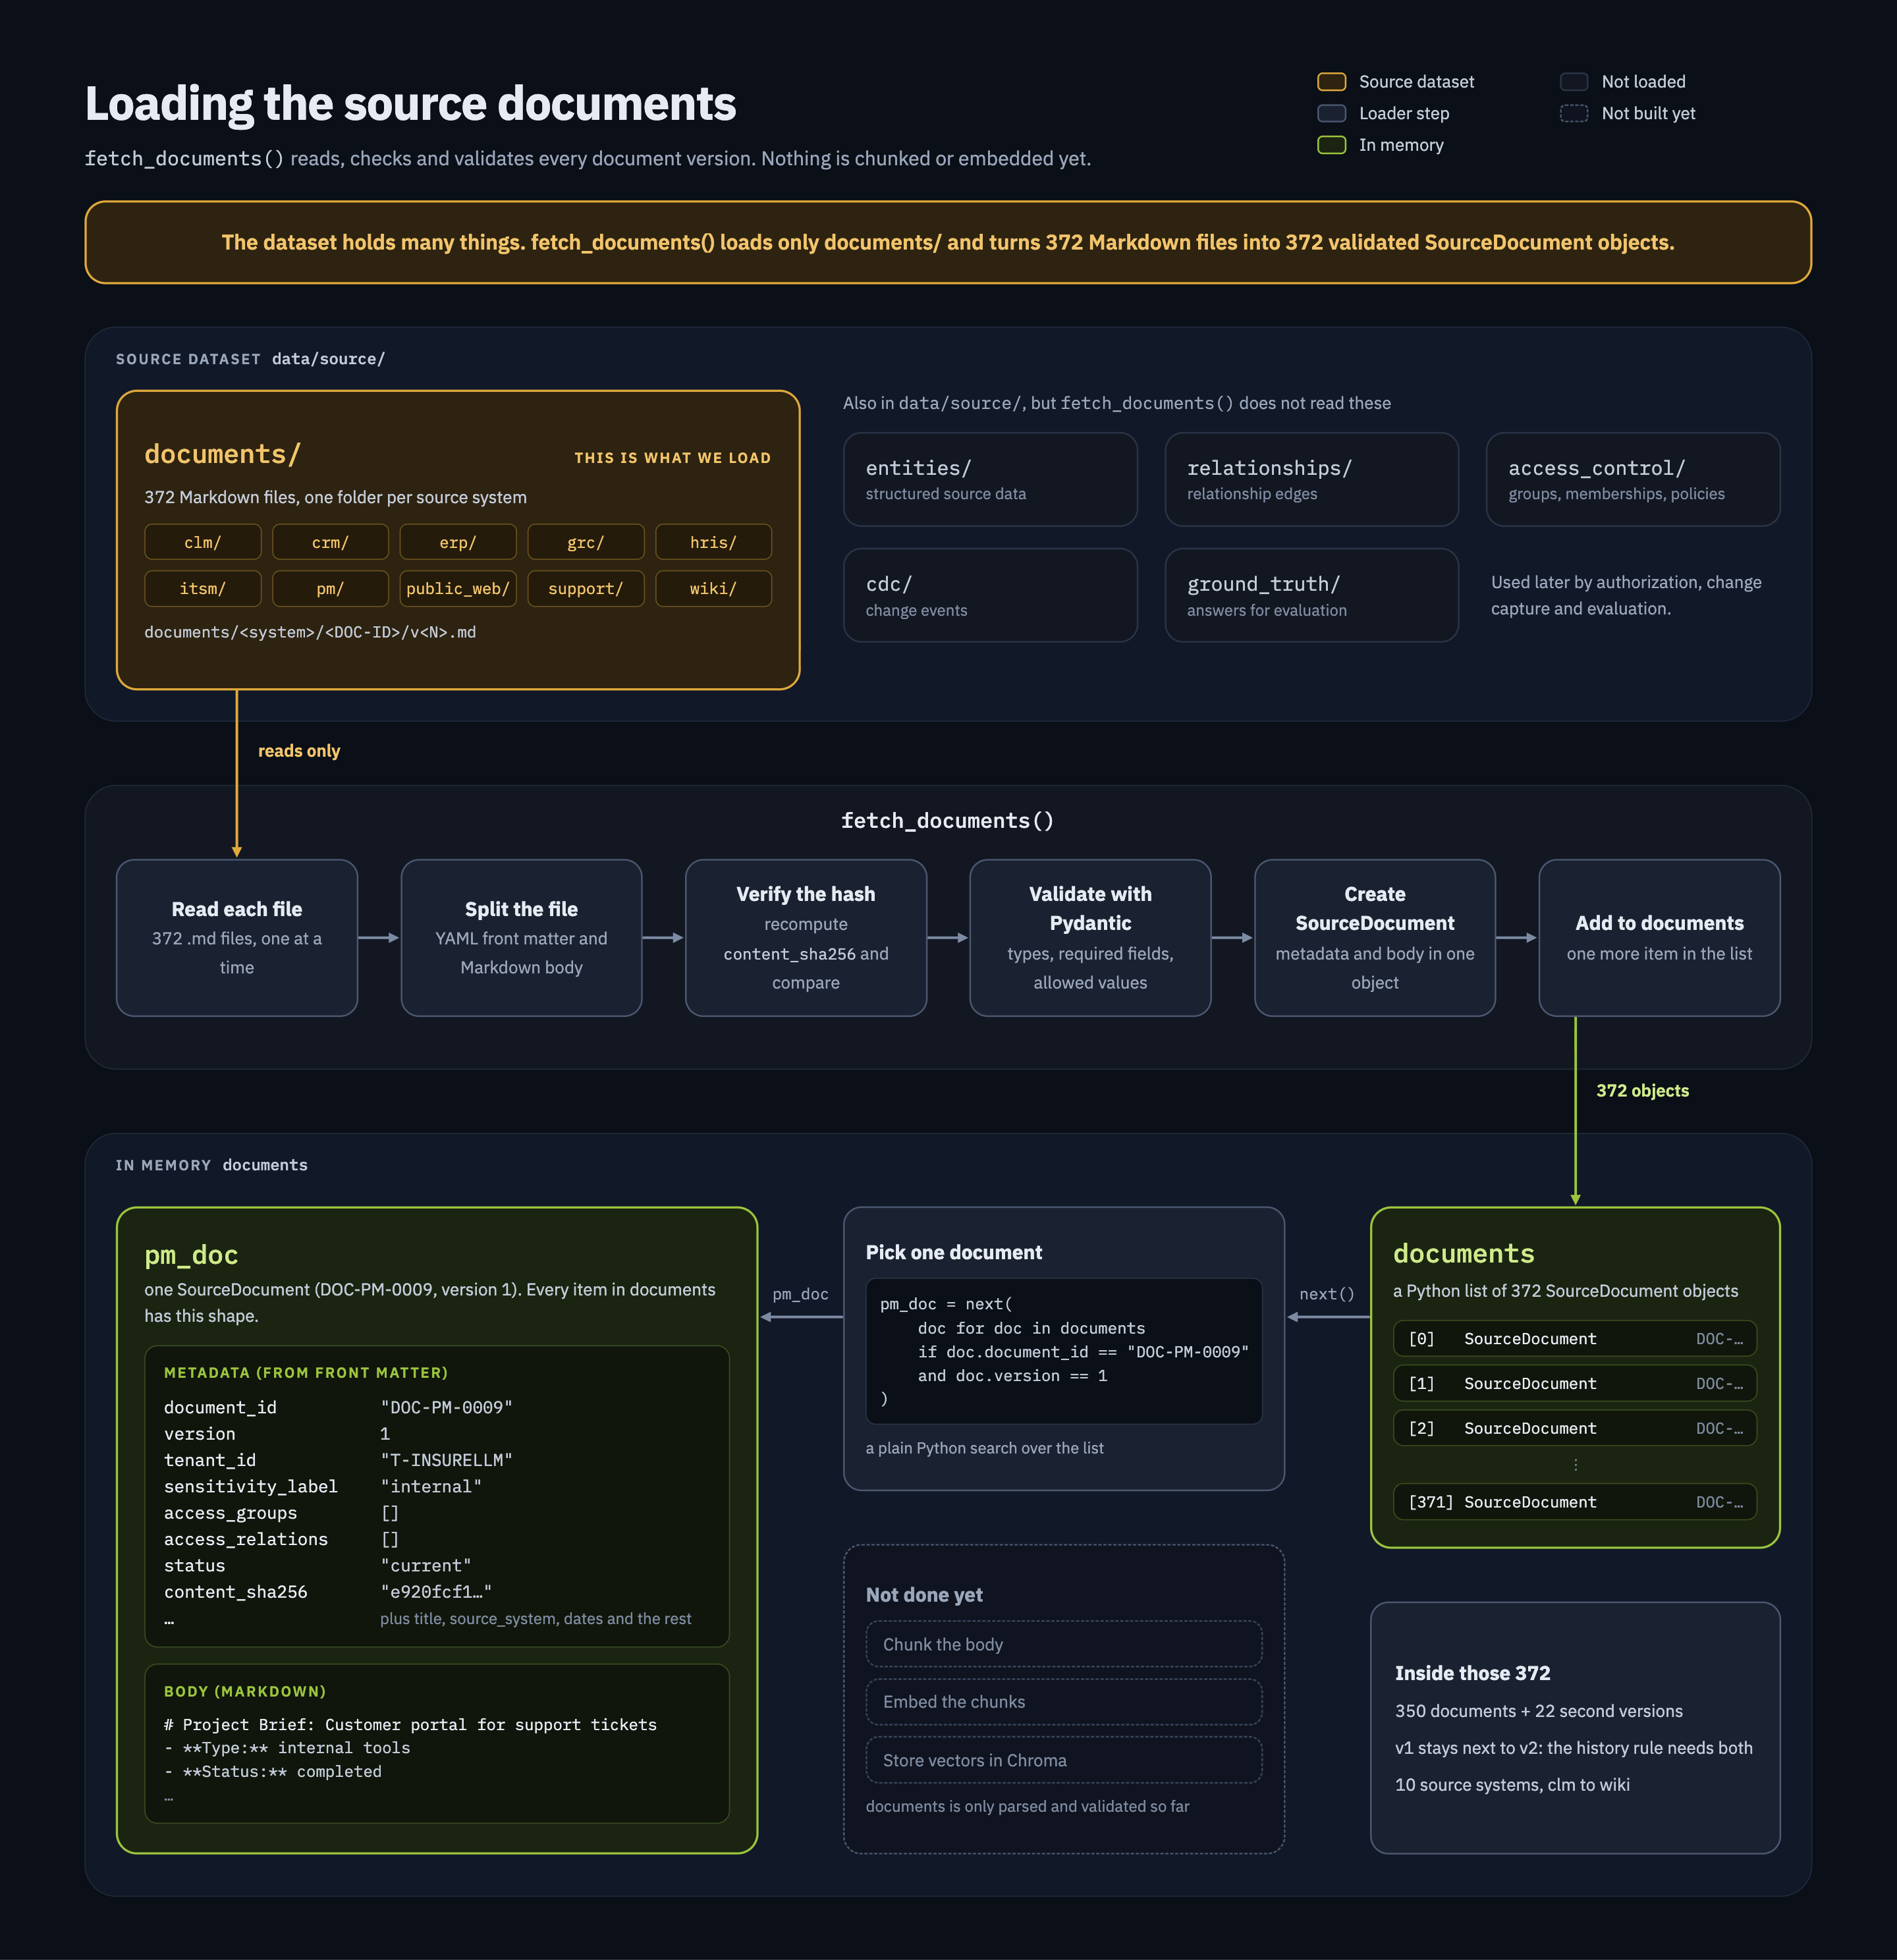

In [ ]:
from pathlib import Path
from hashlib import sha256
from typing import Literal

import yaml
from pydantic import BaseModel, ConfigDict


SOURCE_ROOT = Path(
    "/Users/tarkshya/Work/LLM Engineering/GovernedRAG/data/source"
)

DOCUMENTS_ROOT = SOURCE_ROOT / "documents"


class AccessRelation(BaseModel):
    model_config = ConfigDict(extra="forbid")

    relation: Literal[
        "self",
        "manager_of",
        "account_team_of",
    ]

    subject: str


class SourceDocument(BaseModel):
    model_config = ConfigDict(extra="forbid")

    # Identity
    schema_version: str
    document_id: str
    version: int
    document_version_id: str

    # Content
    title: str
    document_type: str

    # Source / lineage
    source_system: str
    source_uri: str
    source_record_ids: list[str]

    # Entities
    subject_entities: list[str]

    # Governance
    tenant_id: str
    owner_department_id: str
    source_owner_id: str
    sensitivity_label: str
    access_groups: list[str]
    access_relations: list[AccessRelation]
    access_principals: list[str]

    # Location / lifecycle
    region: str
    language: str
    status: str
    supersedes: str | None

    # Provenance
    content_origin: str
    content_sha256: str
    retention_class: str

    # Dates
    created_at: str
    updated_at: str
    valid_from: str
    valid_to: str | None

    # Actual Markdown body
    body: str


def parse_document(path: Path) -> SourceDocument:
    """
    Read one Markdown source document, parse its YAML front matter,
    extract the Markdown body, and verify its content hash.
    """

    text = path.read_text(encoding="utf-8")

    if not text.startswith("---"):
        raise ValueError(f"Missing YAML front matter: {path}")

    parts = text.split("---", 2)

    if len(parts) != 3:
        raise ValueError(f"Invalid front matter structure: {path}")

    _, front_matter, body = parts

    metadata = yaml.safe_load(front_matter)

    if not isinstance(metadata, dict):
        raise ValueError(f"Front matter is not a mapping: {path}")

    body = body.lstrip("\n")

    actual_hash = sha256(body.encode("utf-8")).hexdigest()

    expected_hash = metadata["content_sha256"]

    if actual_hash != expected_hash:
        raise ValueError(
            f"Content hash mismatch: {path}\n"
            f"Expected: {expected_hash}\n"
            f"Actual:   {actual_hash}"
        )

    return SourceDocument(
        **metadata,
        body=body,
    )


def fetch_documents() -> list[SourceDocument]:
    """
    Load every Markdown source document.

    Includes both v1 and v2 documents.
    Ignores .gitkeep and other non-Markdown files.
    """

    documents = []

    for path in DOCUMENTS_ROOT.rglob("*.md"):
        documents.append(parse_document(path))

    print(f"Loaded {len(documents)} documents")

    return documents

In [7]:
documents = fetch_documents()

print(len(documents))
print(documents[0])

Loaded 372 documents
372
schema_version='1.0' document_id='DOC-PM-0009' version=1 document_version_id='DOC-PM-0009@v1' title='Project brief: Customer portal for support tickets' document_type='project_brief' source_system='pm' source_uri='pm://projects/PROJ-009/brief' source_record_ids=['PROJ-009'] subject_entities=['PROJ-009', 'CUST-011', 'CUST-008'] tenant_id='T-INSURELLM' owner_department_id='DEPT-03' source_owner_id='EMP-027' sensitivity_label='internal' access_groups=[] access_relations=[] access_principals=[] region='us' language='en' status='current' supersedes=None content_origin='internal' content_sha256='e920fcf12a6720e5d7c0f760e625ac5b81b3b4f112ed9e6befa736c932fdbd1b' retention_class='standard' created_at='2024-10-07T09:00:00Z' updated_at='2024-10-07T09:00:00Z' valid_from='2024-10-07' valid_to=None body='# Project Brief: Customer portal for support tickets\n\n- **Type:** internal tools\n- **Status:** completed\n- **Owning team:** Commercial and Specialty Platform\n- **Sponso

In [8]:
pm_doc = next(
    doc
    for doc in documents
    if doc.document_id == "DOC-PM-0009"
    and doc.version == 1
)

print(pm_doc.document_version_id)
print(pm_doc.title)
print(pm_doc.body[:500])

DOC-PM-0009@v1
Project brief: Customer portal for support tickets
# Project Brief: Customer portal for support tickets

- **Type:** internal tools
- **Status:** completed
- **Owning team:** Commercial and Specialty Platform
- **Sponsor:** Marcus Johnson
- **Lead:** Jordan K. Bishop
- **Members:** Jordan K. Bishop, Brandon Walker
- **Products:** none
- **Customers:** FastTrack Insurance Services, DriveSmart Insurance
- **Start date:** October 7, 2024
- **Target date:** April 30, 2025
- **Completed:** April 25, 2025
- **Budget:** $85,000

## Goals
Reduce manual 


```
SourceDocument
      │
      ├── body
      │
      └── metadata <- We are here | Step 1: Completed
            │
            ↓
        CHUNKING
            │
            ↓
       Chunk records
            │
            ├── document_id
            ├── document_version_id
            ├── sensitivity
            ├── tenant
            ├── access rules
            ├── content_origin
            ├── chunk_index
            ├── chunk_hash
            └── ...
````

# Step 2: Chunking — Turning `SourceDocument`s into `VectorRecord`s

> 💡 For a governed RAG system, chunking must be **deterministic** — same input, same chunks, same IDs, same hashes — every time.

---

## 1. Where Chunking Fits in the Flow

```
372 SourceDocument objects
        ↓
      CHUNKING
        ↓
multiple chunks per document
        ↓
   VectorRecord
```

---

## 2. What Chunking Needs to Accomplish

For every source document, we need to:

1. Take its `body`
2. Divide it into retrieval-friendly pieces
3. Keep the original text intact
4. Give every chunk a stable `chunk_id`
5. Give it a `chunk_index`
6. Calculate its `chunk_hash`
7. Carry the document's governance metadata forward

### Example: one document → several chunks

```
DOC-PM-0009@v1
        │
        ├── chunk 0
        ├── chunk 1
        ├── chunk 2
        └── chunk 3
```

### What each chunk will eventually become

```
chunk_id
document_id
document_version_id
chunk_index
text
chunk_hash

tenant_id
sensitivity_label
access_groups
access_relations
access_principals
content_origin
...
```

---

## 3. ⚠️ Important Design Choice: No LLM Chunking (for now)

I don't want to immediately use the LLM chunking approach from my old `proIngest.py`.

That old pipeline **asked an LLM to decide the chunks**. For this governed system, we care about:

- deterministic re-ingestion
- stable chunk IDs
- reproducible hashes
- CDC
- idempotent updates
- exact source lineage

### ❌ LLM-decided chunks

**Rejected as the first implementation** — not a reliable source-of-truth transformation for the requirements above.

### ✅ Deterministic Markdown-aware chunking

**Our first implementation.** Conceptually:

```
Markdown document
       ↓
preserve headings/sections
       ↓
split oversized sections
       ↓
controlled overlap
       ↓
stable chunks
```

> 📌 The LLM can be used later where it actually adds value — **retrieval / reranking / query processing** — not as an unnecessary source-of-truth transformation.

---

## 4. Next Piece: `create_chunks`

Our immediate next piece is a function like:

```python
def create_chunks(document: SourceDocument) -> list[VectorRecord]:
    ...
```

> 📌 **Before we write it**, we should settle exactly how **chunk IDs** and **chunk boundaries** work — those decisions affect **CDC and incremental updates** later.

# Step 1 — Markdown section splitter

In [10]:
import re


def split_markdown_sections(text: str):
    sections = []

    current_heading = "Document"
    current_lines = []

    for line in text.splitlines():
        if re.match(r"^#{1,6}\s+", line):
            if current_lines:
                sections.append({
                    "heading": current_heading,
                    "text": "\n".join(current_lines).strip()
                })

            current_heading = line.strip()
            current_lines = []
        else:
            current_lines.append(line)

    if current_lines:
        sections.append({
            "heading": current_heading,
            "text": "\n".join(current_lines).strip()
        })

    return sections

In [11]:
sections = split_markdown_sections(pm_doc.body)

for i, section in enumerate(sections):
    print(f"\n--- SECTION {i} ---")
    print(section["heading"])
    print(section["text"][:500])


--- SECTION 0 ---
# Project Brief: Customer portal for support tickets
- **Type:** internal tools
- **Status:** completed
- **Owning team:** Commercial and Specialty Platform
- **Sponsor:** Marcus Johnson
- **Lead:** Jordan K. Bishop
- **Members:** Jordan K. Bishop, Brandon Walker
- **Products:** none
- **Customers:** FastTrack Insurance Services, DriveSmart Insurance
- **Start date:** October 7, 2024
- **Target date:** April 30, 2025
- **Completed:** April 25, 2025
- **Budget:** $85,000

--- SECTION 1 ---
## Goals
Reduce manual work for customers and for Insurellm support.


# Step 2 — define our chunk size

```
We'll eventually test alternatives such as:
800 / 100
1200 / 200
1600 / 250
````

In [12]:
CHUNK_SIZE = 1200
CHUNK_OVERLAP = 200

In [13]:
def split_text(text, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    chunks = []

    start = 0

    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])

        if end >= len(text):
            break

        start = end - overlap

    return chunks

In [14]:
text = "A" * 2800

chunks = split_text(text)

for i, chunk in enumerate(chunks):
    print(i, len(chunk))

0 1200
1 1200
2 800


# Step 3 — section-aware chunking

```
Markdown document
      ↓
sections
      ↓
if section <= 1200 chars → keep it intact
if section > 1200 chars → split with 200-char overlap 
```

In [15]:
def chunk_section(section):
    text = section["text"]

    if len(text) <= CHUNK_SIZE:
        return [section]

    chunks = split_text(text)

    return [
        {
            "heading": section["heading"],
            "text": chunk
        }
        for chunk in chunks
    ]

In [16]:
def chunk_document(document):
    sections = split_markdown_sections(document.body)

    chunks = []

    for section in sections:
        chunks.extend(chunk_section(section))

    return chunks

In [17]:
chunks = chunk_document(pm_doc)

print(f"Number of chunks: {len(chunks)}")

for i, chunk in enumerate(chunks):
    print(f"\n--- CHUNK {i} ---")
    print(f"Heading: {chunk['heading']}")
    print(f"Length: {len(chunk['text'])}")
    print(chunk["text"][:300])

Number of chunks: 2

--- CHUNK 0 ---
Heading: # Project Brief: Customer portal for support tickets
Length: 421
- **Type:** internal tools
- **Status:** completed
- **Owning team:** Commercial and Specialty Platform
- **Sponsor:** Marcus Johnson
- **Lead:** Jordan K. Bishop
- **Members:** Jordan K. Bishop, Brandon Walker
- **Products:** none
- **Customers:** FastTrack Insurance Services, DriveSmart Insurance


--- CHUNK 1 ---
Heading: ## Goals
Length: 59
Reduce manual work for customers and for Insurellm support.
